In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PRSA_Data_Wanshouxigong_20130301-20170228.csv to PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# load uploaded file
df = pd.read_csv("PRSA_Data_Wanshouxigong_20130301-20170228.csv")

print("Columns in dataset:")
print(df.columns)

df.head()

Columns in dataset:
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


In [ ]:
# Keep only numeric columns
df = df.select_dtypes(include=[np.number])

# Check missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop rows where target is missing (adjust name if needed)
target_column = 'PM2.5'  # change if needed

if target_column not in df.columns:
    raise Exception("Target column not found. Check column names!")

df = df.dropna(subset=[target_column])

# Fill remaining missing values
#df = df.fillna(df.mean())

print("\nDataset shape after cleaning:", df.shape)



Missing values before cleaning:
No       0
year     0
month    0
day      0
hour     0
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64

Dataset shape after cleaning: (34368, 16)


In [ ]:
#Define Features & Target
X = df.drop(target_column, axis=1)
y = df[target_column]

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (27494, 15)
Testing samples: (6874, 15)


In [ ]:
print("\n--- BASELINE (0% Missing Data) ---")

# No missing data → just impute original data
X_train_base, X_test_base = impute_data(X_train, X_test, method="mean")

baseline_results = evaluate_models(X_train_base, X_test_base, y_train, y_test)

for model, metrics in baseline_results.items():
    print(f"{model}: MAE={metrics[0]:.3f}, RMSE={metrics[1]:.3f}, R2={metrics[2]:.3f}")


--- BASELINE (0% Missing Data) ---
Linear Regression: MAE=22.104, RMSE=36.107, R2=0.829
Decision Tree: MAE=15.673, RMSE=32.865, R2=0.859
Random Forest: MAE=11.784, RMSE=24.881, R2=0.919


In [ ]:
#Introduce Missing Data
def introduce_missing_data(X, missing_percent):
    X_missing = X.copy()

    np.random.seed(42)

    # Apply missing per column (better distribution)
    for col in X_missing.columns:
        X_missing.loc[
            X_missing.sample(frac=missing_percent).index, col
        ] = np.nan

    return X_missing

In [ ]:
def impute_data(X_train, X_test, method="mean"):
    if method == "mean":
        imputer = SimpleImputer(strategy='mean')
    elif method == "knn":
        imputer = KNNImputer(n_neighbors=5)

    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    return X_train_imp, X_test_imp

In [ ]:
def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
}

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results[name] = (mae, rmse, r2)

    return results

In [ ]:
missing_levels = [0.05, 0.10, 0.20, 0.30]
imputation_methods = ["mean", "knn"]

final_results = []

for level in missing_levels:

    print(f"\nRunning for {level*100}% missing data...")

    X_train_missing = introduce_missing_data(X_train, level)
    X_test_missing = introduce_missing_data(X_test, level)

    for method in imputation_methods:

        X_train_imp, X_test_imp = impute_data(X_train_missing, X_test_missing, method)

        results = evaluate_models(X_train_imp, X_test_imp, y_train, y_test)

        for model, metrics in results.items():
            final_results.append({
                "Missing %": level * 100,
                "Imputation": method,
                "Model": model,
                "MAE": metrics[0],
                "RMSE": metrics[1],
                "R2": metrics[2]
            })

results_df = pd.DataFrame(final_results)

print("\nFinal Results:")
print(results_df)


Running for 5.0% missing data...

Running for 10.0% missing data...

Running for 20.0% missing data...

Running for 30.0% missing data...

Final Results:
    Missing % Imputation              Model        MAE       RMSE        R2
0         5.0       mean  Linear Regression  23.936692  38.348773  0.807574
1         5.0       mean      Decision Tree  22.402510  38.168862  0.809375
2         5.0       mean      Random Forest  20.897806  35.772759  0.832558
3         5.0        knn  Linear Regression  22.616685  36.876350  0.822067
4         5.0        knn      Decision Tree  20.868859  36.484764  0.825826
5         5.0        knn      Random Forest  19.452704  33.670745  0.851657
6        10.0       mean  Linear Regression  26.063162  41.869819  0.770616
7        10.0       mean      Decision Tree  23.754294  40.766291  0.782548
8        10.0       mean      Random Forest  22.584734  39.118155  0.799775
9        10.0        knn  Linear Regression  23.572413  38.959699  0.801394
10       

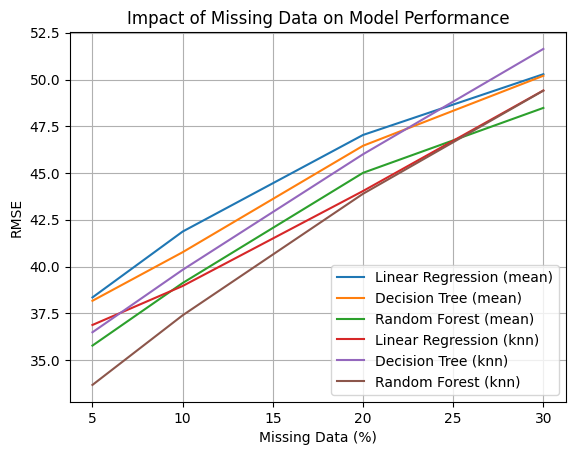

In [ ]:
plt.figure()

for method in results_df['Imputation'].unique():
    subset = results_df[results_df['Imputation'] == method]

    for model in subset['Model'].unique():
        data = subset[subset['Model'] == model]
        plt.plot(data['Missing %'], data['RMSE'], label=f"{model} ({method})")

plt.xlabel("Missing Data (%)")
plt.ylabel("RMSE")
plt.title("Impact of Missing Data on Model Performance")
plt.legend()
plt.grid()

plt.savefig("performance_graph.png")
plt.show()

In [ ]:
results_df.to_csv("results.csv", index=False)

from google.colab import files
files.download("results.csv")
files.download("performance_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

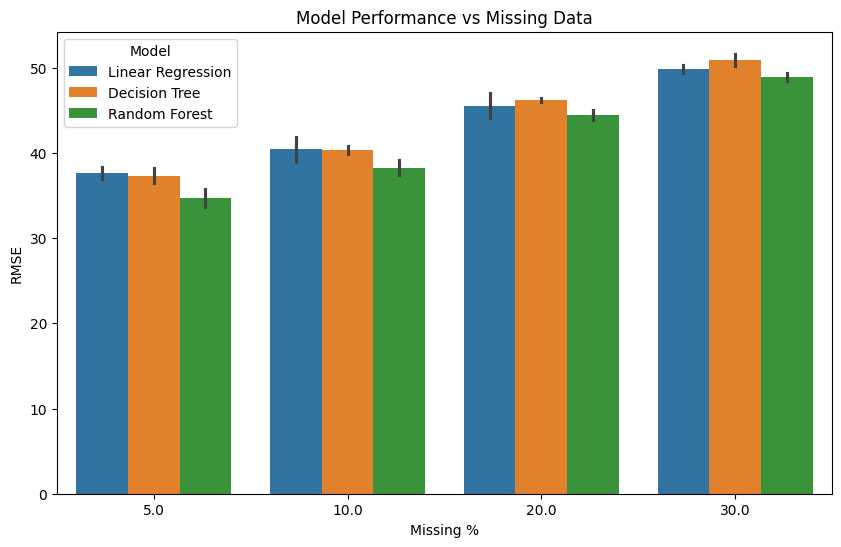

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Missing %",
    y="RMSE",
    hue="Model"
)

plt.title("Model Performance vs Missing Data")
plt.show()

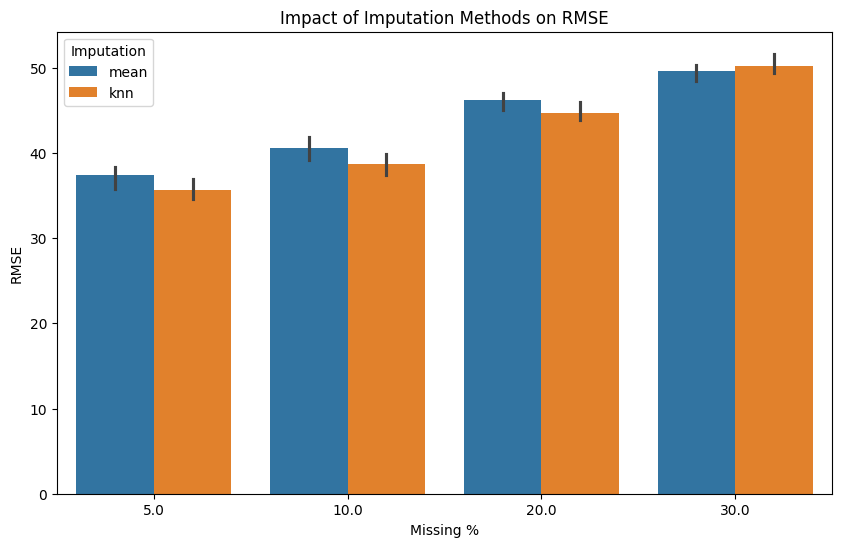

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Missing %",
    y="RMSE",
    hue="Imputation"
)

plt.title("Impact of Imputation Methods on RMSE")
plt.show()

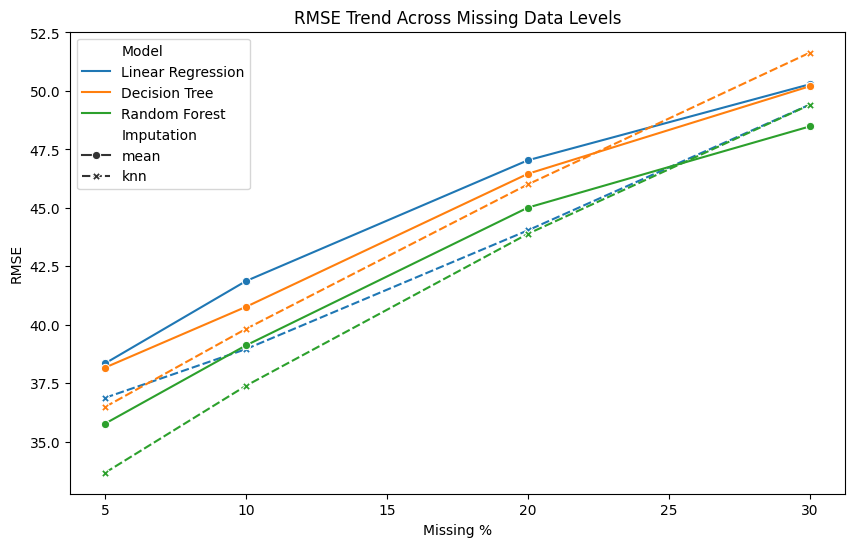

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=results_df,
    x="Missing %",
    y="RMSE",
    hue="Model",
    style="Imputation",
    markers=True
)

plt.title("RMSE Trend Across Missing Data Levels")
plt.show()